# Домашняя работа 
## API был взять с github.com (http://github.com)


### 1 получение пользователя


In [28]:
pip install requests pandas matplotlib

  Using cached matplotlib-3.10.8-cp314-cp314-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp314-cp314-macosx_10_15_universal2.whl.metadata (117 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.1 kB)
  Using cached pillow-12.1.1-cp314-cp314-macosx_11_0_arm64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp314-cp314-macosx_11_0_arm64.whl (8.2 MB)
Using cached contourpy-1.3.3-cp314-cp314-macosx_11_0_arm64.whl (273 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.1-cp314-cp314-macosx_10_15_universal2.whl (2.9 MB)
Using cached kiwisolver-1.5.0-cp314-cp314-macosx_11_0_arm64.whl (64 kB)
Using cached pillow-12.1.1-cp314-cp314-macosx_11_0_arm64.whl (4.7 MB)
Using cached pyparsing-3.3.2

In [21]:
import requests
url="https://api.github.com/"


<span>Поскольку в гитхабе нельзя получить первого пользователя как в вк, но он известен нам, получаем его через никнейм</span>

In [22]:
requests.get(url+"users/mojombo").json()

{'login': 'mojombo',
 'id': 1,
 'node_id': 'MDQ6VXNlcjE=',
 'avatar_url': 'https://avatars.githubusercontent.com/u/1?v=4',
 'gravatar_id': '',
 'url': 'https://api.github.com/users/mojombo',
 'html_url': 'https://github.com/mojombo',
 'followers_url': 'https://api.github.com/users/mojombo/followers',
 'following_url': 'https://api.github.com/users/mojombo/following{/other_user}',
 'gists_url': 'https://api.github.com/users/mojombo/gists{/gist_id}',
 'starred_url': 'https://api.github.com/users/mojombo/starred{/owner}{/repo}',
 'subscriptions_url': 'https://api.github.com/users/mojombo/subscriptions',
 'organizations_url': 'https://api.github.com/users/mojombo/orgs',
 'repos_url': 'https://api.github.com/users/mojombo/repos',
 'events_url': 'https://api.github.com/users/mojombo/events{/privacy}',
 'received_events_url': 'https://api.github.com/users/mojombo/received_events',
 'type': 'User',
 'user_view_type': 'public',
 'site_admin': False,
 'name': 'Tom Preston-Werner',
 'company': '@

In [23]:
# Получаем его репозиторий
repos=requests.get(url+"users/mojombo/repos").json()
for repo in repos:
    print(repo["name"],repo["stargazers_count"])

30daysoflaptops.github.io 8
asteroids 94
benbalter.github.com 6
bert 208
bert.erl 98
bertrpc 168
bower 6
chronic 3256
clippy 936
conceptual_algorithms 6
cubesixel 28
docz-website 1
egitd 113
endo 4
erlang_pipe 20
erlectricity 353
erlectricity-presentation 5
erlenmeyer 8
ernie 467
eventmachine 12
fakegem 4
fixture-scenarios 17
git 11
git-bzr 8
github-flavored-markdown 188
github-gem 6
glowstick 36
god 2216
gollum-demo 74
grit 2008


### Задание 2.

In [39]:

import pandas as pd

def get_top_repos_by_language(language, top_n=20):
    
    params = {
        "q": f"language:{language}",
        "sort": "stars",
        "per_page": top_n
    }
    
    r = requests.get(url+"search/repositories", params=params).json()
    
    if "items" in r:
        repos = r["items"]
        df = pd.DataFrame(repos)[["name", "stargazers_count", "language"]]
        df = df.sort_values("stargazers_count", ascending=False).reset_index(drop=True)
        df.index += 1
        return df
    else:
        print(f"Ошибка запроса для {language}: {r}")
        return pd.DataFrame()   
        return None
topJS=get_top_repos_by_language("JavaScript")
print(topJS.head(10))


                     name  stargazers_count    language
1                   react            244004  JavaScript
2   javascript-algorithms            195784  JavaScript
3              javascript            148123  JavaScript
4                 next.js            138364  JavaScript
5      30-seconds-of-code            127107  JavaScript
6                    node            116302  JavaScript
7                three.js            111397  JavaScript
8                   axios            108655  JavaScript
9        create-react-app            103825  JavaScript
10            awesome-mac            100327  JavaScript


### Задание 3

Среднее количество звезд по языкам:
language
C++            75706.40
JavaScript    109582.55
TypeScript    160667.15
Name: stargazers_count, dtype: float64


<Figure size 1000x600 with 0 Axes>

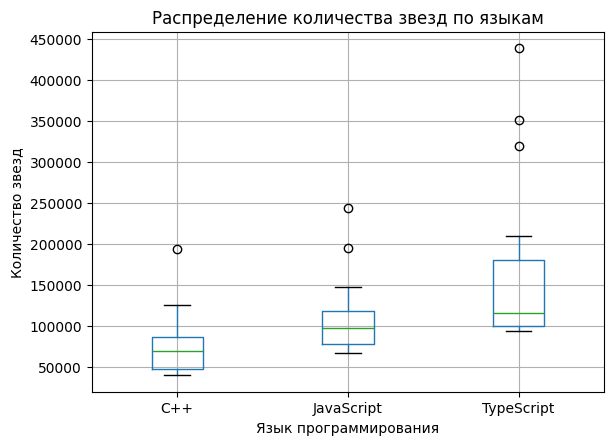

In [40]:
import matplotlib.pyplot as plt
topTS = get_top_repos_by_language("TypeScript")
topCPP = get_top_repos_by_language("C++")
dfTops = pd.concat([topJS,topCPP,topTS])

meanStars = dfTops.groupby("language")["stargazers_count"].mean()
print(f"Среднее количество звезд по языкам:\n{meanStars}")
plt.figure(figsize=(10, 6))
dfTops.boxplot(column="stargazers_count", by="language")
plt.title("Распределение количества звезд по языкам")
plt.suptitle("")
plt.xlabel("Язык программирования")
plt.ylabel("Количество звезд")
plt.show()
